In [6]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
cm_list = ["unv1","prv1","cluster_c"]
load_list_dict = dict()
load_list_dict["unv1"] = range(1,11)
load_list_dict["prv1"] = range(1,11)
load_list_dict["cluster_c"] = range(5,51,5)
seed_list = [1,2,3,4,5]
scheme = "dringsu2"
delay_list_dict = dict()
delay_list_dict["unv1"] = [2,4,6]
delay_list_dict["prv1"] = [2,4,6]
delay_list_dict["cluster_c"] = [2,4,6,8,24,36]

In [5]:
import os

cm_topickle_list = ["cluster_c"]
delay_topickle_list_dict = dict()
delay_topickle_list_dict["cluster_c"] = [24,36]
pickletag = "_2"
sumfile = "fct_summary.txt"
datadict = dict()
with open(sumfile,'a') as fw:
    for cm in cm_topickle_list:
        for delay in delay_topickle_list_dict[cm]:
            if os.path.exists(f"{cm}/outfiles/{scheme}_delay{delay}_load{load_list_dict[cm][0]}_seed{seed_list[0]}.out"):
                for load in load_list_dict[cm]:
                    for seed in seed_list:
                        outfile = f"{cm}/outfiles/{scheme}_delay{delay}_load{load}_seed{seed}.out"
                        durationlist = list()
                        sizelist = list()
                        startlist = list()
                        with open(outfile,'r') as fr:
                            lines = fr.readlines()
                            for line in lines:
                                tokens = line.split()
                                if tokens[0] == "FCT":
                                    durationlist.append(float(tokens[2]))
                                    sizelist.append(int(tokens[1]))
                                    startlist.append(float(tokens[3]))
                        durationlist.sort()
                        datadict[outfile] = [durationlist,sizelist,startlist]
                        
                        fw.write(f"{outfile}\t{sum(durationlist)/len(durationlist)}\t{durationlist[int(len(durationlist)*0.5)]}\t{durationlist[int(len(durationlist)*0.99)]}\t{durationlist[int(len(durationlist)*0.9999)]}\n")

            # intentional -- repeatedly save current progress
            # with open(f'{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_failure_controller.pickle', 'wb') as handle:
            with open(f'{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_failure_controller_{cm}{pickletag}.pickle', 'wb') as handle:
                pickle.dump(datadict, handle, protocol=pickle.HIGHEST_PROTOCOL)

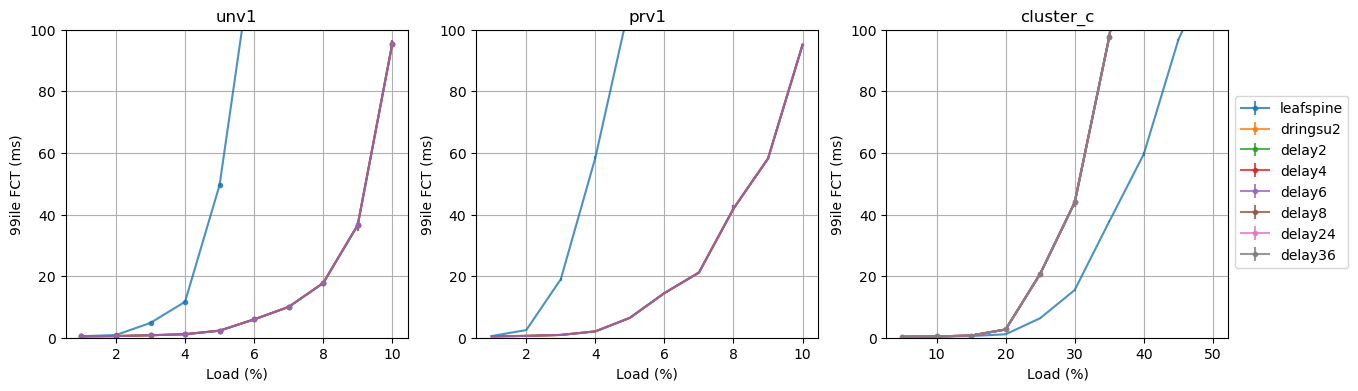

In [7]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p99

plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotevalmaindatadict:
            plotevalmaindatadict[cm] = dict()
        plotevalmaindatadict[cm][outfile] = p99


markerlist = ['o','x']
nr = 1
nc = len(cm_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4))
for ic,cm in enumerate(cm_list):

    for myscheme in ["leafspine","dringsu2"]:
        fct_list = list()
        for load in load_list_dict[cm]:
            fct_list_allseeds = list()
            for seed in seed_list:
                outfile = f"{cm}/outfiles/{myscheme}_load{load}_seed{seed}.out"
                p99 = plotevalmaindatadict[cm][outfile]
                fct_list_allseeds.append(p99)
            fct_list.append(fct_list_allseeds)
        if ic==0:
            axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker='.', label=myscheme,alpha=0.8)
        else:
            axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=',',alpha=0.8)


    for delay in [2,4,6]:
        fct_list = list()
        for load in load_list_dict[cm]:
            fct_list_allseeds = list()
            for seed in seed_list:
                outfile = f"{cm}/outfiles/{scheme}_delay{delay}_load{load}_seed{seed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)
            fct_list.append(fct_list_allseeds)
        if ic==0:
            axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker='.', label=f"delay{delay}",alpha=0.8)
        else:
            axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker=',',alpha=0.8)
    
    if cm=="cluster_c":
        for delay in [8,24,36]:
            fct_list = list()
            for load in load_list_dict[cm]:
                fct_list_allseeds = list()
                for seed in seed_list:
                    outfile = f"{cm}/outfiles/{scheme}_delay{delay}_load{load}_seed{seed}.out"
                    p99 = plotdatadict[cm][outfile]
                    fct_list_allseeds.append(p99)
                fct_list.append(fct_list_allseeds)
            axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker='.', label=f"delay{delay}",alpha=0.8)

    
    axs[ic].set_xlabel("Load (%)")
    axs[ic].set_ylabel("99ile FCT (ms)")
    axs[ic].set_ylim(0,100)
    axs[ic].set_title(cm)
    axs[ic].grid(True)
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))